## Problem Statement
#### Currently, the organization lacks visibility into:

* Which product lines deliver the highest gross margin
* Whether high-sales products are actually profitable.
* How profitability varies across product divisions.
* Which products represent margin risk.

| Field | Description |
|---|---|
| Row ID | Unique row identifier |
| Order ID | Unique order identifier |
| Order Date | Date of order |
| Ship Date | Date of shipment |
| Ship Mode | Shipping method of order |
| Customer ID | Unique customer identifier |
| Country/Region | Country or region of customer |
| City | City of customer |
| State/Province | State/province of customer |
| Postal Code | Postal code / zip code of customer |
| Division | Product division |
| Region | Region of customer |
| Product ID | Unique product identifier |
| Product Name | Product long name |
| Sales | Total sales value of order |
| Units | Total units of order |
| Gross Profit | Gross profit of order (Sales - Cost) |
| Cost | Cost to manufacture |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv("Nassau Candy Distributor.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


# 1.Data Cleaning and Validation

# Explore the data.

In [4]:
# shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (10194, 18)


In [5]:
# columns in the dataset
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='str')


In [6]:
# Data types of the columns
print("Data types of the columns:\n", df.dtypes)

Data types of the columns:
 Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


In [7]:
# Statistical summary of the dataset
print("Statistical summary of the dataset:\n", df.describe())

Statistical summary of the dataset:
              Row ID    Customer ID         Sales         Units  Gross Profit  \
count  10194.000000   10194.000000  10194.000000  10194.000000  10194.000000   
mean    5097.500000  134468.961154     13.908537      3.791838      9.166451   
std     2942.898656   20231.483007     11.341020      2.228317      6.643740   
min        1.000000  100006.000000      1.250000      1.000000      0.250000   
25%     2549.250000  117212.000000      7.200000      2.000000      4.900000   
50%     5097.500000  133550.000000     10.800000      3.000000      7.470000   
75%     7645.750000  152051.000000     18.000000      5.000000     12.250000   
max    10194.000000  192314.000000    260.000000     14.000000    130.000000   

               Cost  
count  10194.000000  
mean       4.742087  
std        5.061647  
min        0.600000  
25%        2.400000  
50%        3.600000  
75%        5.700000  
max      130.000000  


# Validate the data.

In [8]:
# Check for missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [9]:
# Check for zero or negative Sales rows.
zero_sales = df[df["Sales"] <= 0]
zero_sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


In [10]:
# Check for zero Units rows.
zero_units = df[df["Units"] <= 0]
zero_units

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [12]:
df['Product Name'].unique()

<StringArray>
[       'Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
 'Wonka Bar - Nutty Crunch Surprise',    'Wonka Bar -Scrumdiddlyumptious',
         'Wonka Bar - Fudge Mallows',                         'Wonka Gum',
                         'Kazookles',                'Lickable Wallpaper',
              'Fizzy Lifting Drinks',                       'Laffy Taffy',
                         'SweeTARTS',                             'Nerds',
                       'Hair Toffee',            'Everlasting Gobstopper',
                           'Fun Dip']
Length: 15, dtype: str

In [13]:
df["Product Name"] = df["Product Name"].str.replace("Wonka Bar -Scrumdiddlyumptious", "Wonka Bar - Scrumdiddlyumptious")

In [14]:
df["Product Name"].unique()

<StringArray>
[       'Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
 'Wonka Bar - Nutty Crunch Surprise',   'Wonka Bar - Scrumdiddlyumptious',
         'Wonka Bar - Fudge Mallows',                         'Wonka Gum',
                         'Kazookles',                'Lickable Wallpaper',
              'Fizzy Lifting Drinks',                       'Laffy Taffy',
                         'SweeTARTS',                             'Nerds',
                       'Hair Toffee',            'Everlasting Gobstopper',
                           'Fun Dip']
Length: 15, dtype: str

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")

In [16]:
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

datetime64[us]
datetime64[us]


# 2. Probability Metrics Calculation:

In [17]:
product_margin = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Units': 'sum'
}).reset_index()

# Gross Margin %
product_margin['Gross_Margin'] = (product_margin['Gross Profit'] / product_margin['Sales']) * 100

# Profit per unit
product_margin['Profit_per_unit'] = product_margin['Gross Profit'] / product_margin['Units']

# Total profit contribution
product_margin['Total_profit_contribution'] = product_margin['Gross Profit']

print(product_margin)

                         Product Name     Sales  Gross Profit  Units  \
0              Everlasting Gobstopper    130.00        104.00     13   
1                Fizzy Lifting Drinks     78.75         47.25     21   
2                             Fun Dip     12.00          4.80      8   
3                         Hair Toffee     76.50         59.50     17   
4                           Kazookles   1205.75         92.75    371   
5                         Laffy Taffy     53.73         33.48     27   
6                  Lickable Wallpaper   7860.00       3930.00    393   
7                               Nerds     15.00          7.00     10   
8                           SweeTARTS     61.50         28.70     41   
9           Wonka Bar - Fudge Mallows  24890.40      16593.60   6914   
10         Wonka Bar - Milk Chocolate  26867.75      17443.37   8267   
11  Wonka Bar - Nutty Crunch Surprise  23574.95      16819.95   6755   
12    Wonka Bar - Scrumdiddlyumptious  27874.80      19357.50   

### Report – Product Profitability Summary

This analysis evaluates product performance using **Gross Margin (%), Profit per Unit, and Total Profit Contribution**.

The **Wonka Bar product line** contributes the highest overall profit. Among them, **Wonka Bar – Scrumdiddlyumptious** generates the largest total profit (19,357.50), followed by **Triple Dazzle Caramel** and **Milk Chocolate**, indicating that Wonka Bars are the primary revenue and profit drivers for the company.

In terms of **profitability efficiency**, **Everlasting Gobstopper** has the highest gross margin (80%), followed by **Hair Toffee (77.78%)**, showing that these products generate strong profit relative to their sales.

However, **Kazookles** has the lowest margin (7.69%) and the lowest profit per unit, suggesting potential pricing or cost issues that may require review.

Overall, the portfolio shows strong profitability driven mainly by **Wonka Bars**, while a few low-margin products may need optimization to improve overall business performance.


# 3.Product-Level Profitability Analysis:

In [18]:
#  Rank products by:
#  1.Gross profit
#  2.Gross margin

# Rank by Gross Profit
product_margin['Rank_gross_profit'] = product_margin['Gross Profit'].rank(ascending=False)
rank_gross_profit = product_margin.sort_values(by='Gross Profit', ascending=False)
rank_gross_profit

,Product Name,Sales,Gross Profit,Units,Gross_Margin,Profit_per_unit,Total_profit_contribution,Rank_gross_profit
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,19357.50,1.0
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,18610.20,2.0
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,17443.37,3.0
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,16819.95,4.0
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,16593.60,5.0
6,Lickable Wallpaper,7860.00,3930.00,393,50.000000,10.00,3930.00,6.0
14,Wonka Gum,597.50,310.70,478,52.000000,0.65,310.70,7.0
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,104.00,8.0
4,Kazookles,1205.75,92.75,371,7.692308,0.25,92.75,9.0
3,Hair Toffee,76.50,59.50,17,77.777778,3.50,59.50,10.0


# Report:
* Highest Gross Profit Product is Wonka Bar - Scrumdiddlyumptious

In [19]:
# 2. Gross Margin.
product_margin['Rank_gross_margin'] = product_margin['Gross_Margin'].rank(ascending=False)
rank_gross_margin = product_margin.sort_values(by='Gross_Margin', ascending=False)
rank_gross_margin

,Product Name,Sales,Gross Profit,Units,Gross_Margin,Profit_per_unit,Total_profit_contribution,Rank_gross_profit,Rank_gross_margin
0,Everlasting Gobstopper,130.00,104.00,13,80.000000,8.00,104.00,8.0,1.0
3,Hair Toffee,76.50,59.50,17,77.777778,3.50,59.50,10.0,2.0
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755,71.346705,2.49,16819.95,4.0,3.0
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50,7743,69.444444,2.50,19357.50,1.0,4.0
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,6914,66.666667,2.40,16593.60,5.0,5.0
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,7596,65.333333,2.45,18610.20,2.0,6.0
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,8267,64.923077,2.11,17443.37,3.0,7.0
5,Laffy Taffy,53.73,33.48,27,62.311558,1.24,33.48,12.0,8.0
1,Fizzy Lifting Drinks,78.75,47.25,21,60.000000,2.25,47.25,11.0,9.0
14,Wonka Gum,597.50,310.70,478,52.000000,0.65,310.70,7.0,10.0


# Report:
* Highest Gross Margin Product is Everlasting Gobstopper

In [20]:
#  Identify:
# 1. High-profit / high-margin products.
# 2. High-sales / low-margin products.
# 3. Low-sales / low-profit products.

# 1. High-profit / high-margin products.
# Average values
avg_profit = product_margin['Gross Profit'].mean()
avg_margin = product_margin['Gross_Margin'].mean()

# High profit and high margin products
high_profit_high_margin = product_margin[
    (product_margin['Gross Profit'] > avg_profit) &
    (product_margin['Gross_Margin'] > avg_margin)
]

print(high_profit_high_margin[['Product Name','Gross Profit','Gross_Margin']])


                         Product Name  Gross Profit  Gross_Margin
9           Wonka Bar - Fudge Mallows      16593.60     66.666667
10         Wonka Bar - Milk Chocolate      17443.37     64.923077
11  Wonka Bar - Nutty Crunch Surprise      16819.95     71.346705
12    Wonka Bar - Scrumdiddlyumptious      19357.50     69.444444
13  Wonka Bar - Triple Dazzle Caramel      18610.20     65.333333


## Report : High-profit and High-margin products
High-profit and high-margin products are primarily from the Wonka Bar category. These products contribute the most to overall profitability due to strong sales and healthy margins, making them the key drivers of business performance.

In [21]:
# 2. High-sales / low-margin products.
avg_sales = product_margin['Sales'].mean()
avg_margin = product_margin['Gross_Margin'].mean()
high_sales_low_margin = product_margin[
    (product_margin['Sales'] > avg_sales) &
    (product_margin['Gross_Margin'] < avg_margin)
]
print(high_sales_low_margin[['Product Name','Sales','Gross_Margin']])

Empty DataFrame
Columns: [Product Name, Sales, Gross_Margin]
Index: []


## Report:High-Sales / Low-Margin Products:
After analyzing the dataset, no products were found in the high-sales but low-margin category. This indicates that products with high sales also maintain relatively strong profit margins. In particular, the Wonka Bar product line generates high sales while still maintaining healthy margins, which contributes significantly to overall profitability.

In [22]:
# 3. Low-sales / low-profit products.
avg_sales = product_margin['Sales'].mean()
avg_profit = product_margin['Gross Profit'].mean()
low_sales_low_profit = product_margin[
    (product_margin['Sales'] < avg_sales) &
    (product_margin['Gross Profit'] < avg_profit)
]
print(low_sales_low_profit[['Product Name','Sales','Gross Profit']])

              Product Name    Sales  Gross Profit
0   Everlasting Gobstopper   130.00        104.00
1     Fizzy Lifting Drinks    78.75         47.25
2                  Fun Dip    12.00          4.80
3              Hair Toffee    76.50         59.50
4                Kazookles  1205.75         92.75
5              Laffy Taffy    53.73         33.48
6       Lickable Wallpaper  7860.00       3930.00
7                    Nerds    15.00          7.00
8                SweeTARTS    61.50         28.70
14               Wonka Gum   597.50        310.70


## Low-Sales / Low-Profit Products:

The analysis identified several products that fall into the low-sales and low-profit category. These include Everlasting Gobstopper, Fizzy Lifting Drinks, Fun Dip, Hair Toffee, Kazookles, Laffy Taffy, Nerds, SweeTARTS, and Wonka Gum. These products generate sales and profit levels below the overall dataset average.

Although some of these products maintain reasonable margins, their overall contribution to total revenue and profit is relatively small due to lower sales volumes. From a business perspective, the company may consider improving marketing, adjusting pricing strategies, or reviewing product demand to enhance their performance.

# 5.Division-Level Performance Analysis
* Aggregate metrics by Division

**Compare**:
* Average margin by division
* Revenue vs profit imbalance
• Identify divisions with:
* Strong financial efficiency
* Structural margin issues

In [23]:
# Aggregate metrics by division:

df['Gross_Margin'] = df['Gross Profit'] / df['Sales']
division_summary = df.groupby('Division').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Gross_Margin': 'mean'
}).reset_index()

division_summary

,Division,Sales,Gross Profit,Gross_Margin
0,Chocolate,131692.90,88824.62,0.674582
1,Other,9663.25,4333.45,0.376725
2,Sugar,427.48,284.73,0.576890


In [24]:
division_summary['Gross_Margin_%'] = division_summary['Gross_Margin'] * 100
division_summary

,Division,Sales,Gross Profit,Gross_Margin,Gross_Margin_%
0,Chocolate,131692.90,88824.62,0.674582,67.458162
1,Other,9663.25,4333.45,0.376725,37.672457
2,Sugar,427.48,284.73,0.576890,57.689001


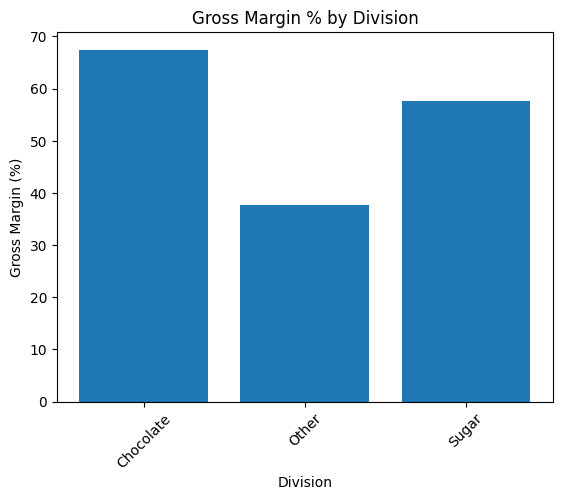

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(division_summary['Division'], division_summary['Gross_Margin_%'])
plt.title("Gross Margin % by Division")
plt.xlabel("Division")
plt.ylabel("Gross Margin (%)")
plt.xticks(rotation=45)
plt.show()

In [26]:
# Average Margin By division:
avg_margin_by_division = division_summary[['Division', 'Gross_Margin_%']]
avg_margin_by_division

,Division,Gross_Margin_%
0,Chocolate,67.458162
1,Other,37.672457
2,Sugar,57.689001


In [27]:
# Revenue vs Profit Imbalance:
division_summary['Profit_Ratio'] = division_summary['Gross Profit'] / division_summary['Sales']
division_summary

,Division,Sales,Gross Profit,Gross_Margin,Gross_Margin_%,Profit_Ratio
0,Chocolate,131692.90,88824.62,0.674582,67.458162,0.674483
1,Other,9663.25,4333.45,0.376725,37.672457,0.448446
2,Sugar,427.48,284.73,0.576890,57.689001,0.666066


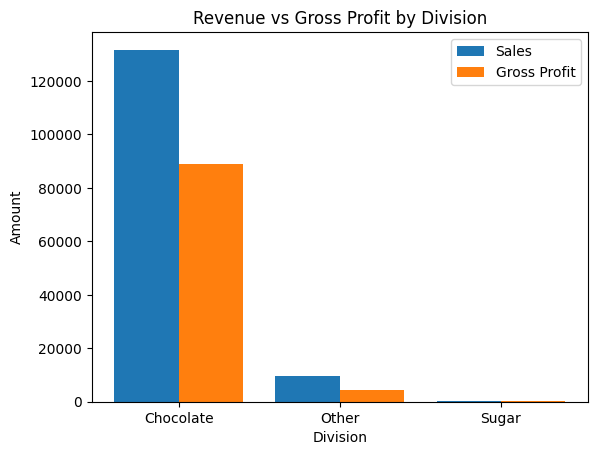

In [28]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(division_summary['Division']))

plt.figure()
plt.bar(x - 0.2, division_summary['Sales'], width=0.4, label='Sales')
plt.bar(x + 0.2, division_summary['Gross Profit'], width=0.4, label='Gross Profit')

plt.xticks(x, division_summary['Division'])
plt.title("Revenue vs Gross Profit by Division")
plt.xlabel("Division")
plt.ylabel("Amount")
plt.legend()

plt.show()

In [29]:
avg_margin = division_summary['Profit_Ratio'].mean()

division_summary['Imbalance_Flag'] = division_summary['Profit_Ratio'].apply(
    lambda x: 'Balanced' if x >= avg_margin else 'Imbalance'
)

division_summary

,Division,Sales,Gross Profit,Gross_Margin,Gross_Margin_%,Profit_Ratio,Imbalance_Flag
0,Chocolate,131692.90,88824.62,0.674582,67.458162,0.674483,Balanced
1,Other,9663.25,4333.45,0.376725,37.672457,0.448446,Imbalance
2,Sugar,427.48,284.73,0.576890,57.689001,0.666066,Balanced


In [31]:
# Strong financial efficiency :
# Structural margin issues:

avg_margin = division_summary['Gross_Margin'].mean()
avg_sales = division_summary['Sales'].mean()

def classify(row):
    if row['Gross_Margin'] >= avg_margin and row['Sales'] >= avg_sales:
        return 'Strong Financial Efficiency'
    elif row['Gross_Margin'] < avg_margin and row['Sales'] >= avg_sales:
        return 'Structural Margin Issues'
    else:
        return 'Underutilized / Low Scale'

division_summary['Category'] = division_summary.apply(classify, axis=1)
division_summary

,Division,Sales,Gross Profit,Gross_Margin,Gross_Margin_%,Profit_Ratio,Imbalance_Flag,Category
0,Chocolate,131692.90,88824.62,0.674582,67.458162,0.674483,Balanced,Strong Financial Efficiency
1,Other,9663.25,4333.45,0.376725,37.672457,0.448446,Imbalance,Underutilized / Low Scale
2,Sugar,427.48,284.73,0.576890,57.689001,0.666066,Balanced,Underutilized / Low Scale


## 7.Profit Concentration (Pareto) Analysis
**Determine % of products contributing:**
* 80% of revenue
* 80% of profit

**Detect congestion-prone states or regionIdentify over-dependency risks**


In [33]:
product_summary = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).reset_index()
product_summary

,Product Name,Sales,Gross Profit
0,Everlasting Gobstopper,130.00,104.00
1,Fizzy Lifting Drinks,78.75,47.25
2,Fun Dip,12.00,4.80
3,Hair Toffee,76.50,59.50
4,Kazookles,1205.75,92.75
5,Laffy Taffy,53.73,33.48
6,Lickable Wallpaper,7860.00,3930.00
7,Nerds,15.00,7.00
8,SweeTARTS,61.50,28.70
9,Wonka Bar - Fudge Mallows,24890.40,16593.60


In [34]:
sales_pareto = product_summary.sort_values(by='Sales', ascending=False).copy()
sales_pareto

,Product Name,Sales,Gross Profit
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50
10,Wonka Bar - Milk Chocolate,26867.75,17443.37
9,Wonka Bar - Fudge Mallows,24890.40,16593.60
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95
6,Lickable Wallpaper,7860.00,3930.00
4,Kazookles,1205.75,92.75
14,Wonka Gum,597.50,310.70
0,Everlasting Gobstopper,130.00,104.00
1,Fizzy Lifting Drinks,78.75,47.25


In [35]:
sales_pareto['Cum_Sales'] = sales_pareto['Sales'].cumsum()
total_sales = sales_pareto['Sales'].sum()

sales_pareto['Cum_Sales_%'] = sales_pareto['Cum_Sales'] / total_sales * 100
sales_pareto

,Product Name,Sales,Gross Profit,Cum_Sales,Cum_Sales_%
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,28485.00,20.090472
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50,56359.80,39.750569
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,83227.55,58.700394
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,108117.95,76.255595
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,131692.90,92.883008
6,Lickable Wallpaper,7860.00,3930.00,139552.90,98.426666
4,Kazookles,1205.75,92.75,140758.65,99.277082
14,Wonka Gum,597.50,310.70,141356.15,99.698498
0,Everlasting Gobstopper,130.00,104.00,141486.15,99.790187
1,Fizzy Lifting Drinks,78.75,47.25,141564.90,99.845730


In [40]:
# Top 80% revenue products:
top_80_sales = sales_pareto[sales_pareto['Cum_Sales_%'] <= 80]
top_80_sales[['Product Name', 'Sales', 'Cum_Sales_%']]

,Product Name,Sales,Cum_Sales_%
13,Wonka Bar - Triple Dazzle Caramel,28485.00,20.090472
12,Wonka Bar - Scrumdiddlyumptious,27874.80,39.750569
10,Wonka Bar - Milk Chocolate,26867.75,58.700394
9,Wonka Bar - Fudge Mallows,24890.40,76.255595


In [38]:
profit_pareto = product_summary.sort_values(by='Gross Profit', ascending=False).copy()

profit_pareto['Cum_Profit'] = profit_pareto['Gross Profit'].cumsum()
total_profit = profit_pareto['Gross Profit'].sum()

profit_pareto['Cum_Profit_%'] = profit_pareto['Cum_Profit'] / total_profit * 100
profit_pareto

,Product Name,Sales,Gross Profit,Cum_Profit,Cum_Profit_%
12,Wonka Bar - Scrumdiddlyumptious,27874.80,19357.50,19357.50,20.715882
13,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,37967.70,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,55411.07,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,72231.02,77.299717
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,88824.62,95.057747
6,Lickable Wallpaper,7860.00,3930.00,92754.62,99.263528
14,Wonka Gum,597.50,310.70,93065.32,99.596031
0,Everlasting Gobstopper,130.00,104.00,93169.32,99.707329
4,Kazookles,1205.75,92.75,93262.07,99.806588
3,Hair Toffee,76.50,59.50,93321.57,99.870263


In [41]:
# Top 80% profit products:
top_80_profit = profit_pareto[profit_pareto['Cum_Profit_%'] <= 80]
top_80_profit[['Product Name', 'Gross Profit', 'Cum_Profit_%']]

,Product Name,Gross Profit,Cum_Profit_%
12,Wonka Bar - Scrumdiddlyumptious,19357.50,20.715882
13,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023
10,Wonka Bar - Milk Chocolate,17443.37,59.299454
11,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717


## 8.Cost Structure Diagnostics:
* Cost vs sales scatter analysis

**Identify:**

* Cost-heavy, margin-poor products
* Pricing inefficiencies

**Flag products needing:**

* Repricing
* Cost renegotiation
* Discontinuation review

In [42]:
# Product level Data:

product_diag = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Cost': 'sum',
    'Gross Profit': 'sum',
    'Units': 'sum'
}).reset_index()

# Create metrics
product_diag['Gross_Margin'] = product_diag['Gross Profit'] / product_diag['Sales']
product_diag['Cost_Ratio'] = product_diag['Cost'] / product_diag['Sales']

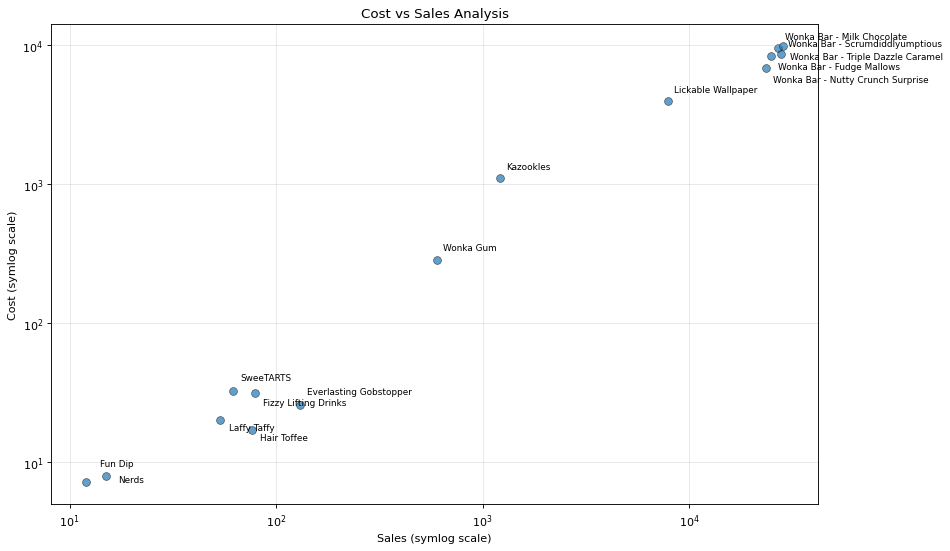

In [61]:
# Cost vs Sales Analysis:
import matplotlib.pyplot as plt

# Reset any previous rcParams
plt.rcdefaults()

fig, ax = plt.subplots(figsize=(12, 7), dpi=80)  # smaller + lower dpi

ax.scatter(product_diag['Sales'], product_diag['Cost'],
        s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

# Simple labels with alternating offsets
for i in range(len(product_diag)):
    offset_y = 8 if i % 2 == 0 else -12
    ax.annotate(
        product_diag['Product Name'].iloc[i],
        (product_diag['Sales'].iloc[i] + 1, product_diag['Cost'].iloc[i] + 1),
        xytext=(6, offset_y),
        textcoords='offset points',
        fontsize=8
    )

ax.set_xscale('symlog')  # symlog handles 0 values safely
ax.set_yscale('symlog')
ax.set_xlabel("Sales (symlog scale)")
ax.set_ylabel("Cost (symlog scale)")
ax.set_title("Cost vs Sales Analysis")
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
avg_margin = product_diag['Gross_Margin'].mean()
avg_cost_ratio = product_diag['Cost_Ratio'].mean()

In [ ]:
# Cost-heavy, margin-poor products:
cost_heavy = product_diag[
    (product_diag['Gross_Margin'] < avg_margin) &
    (product_diag['Cost_Ratio'] > avg_cost_ratio)
]

cost_heavy

,Product Name,Sales,Cost,Gross Profit,Units,Gross_Margin,Cost_Ratio
2,Fun Dip,12.00,7.2,4.80,8,0.400000,0.600000
4,Kazookles,1205.75,1113.0,92.75,371,0.076923,0.923077
6,Lickable Wallpaper,7860.00,3930.0,3930.00,393,0.500000,0.500000
7,Nerds,15.00,8.0,7.00,10,0.466667,0.533333
8,SweeTARTS,61.50,32.8,28.70,41,0.466667,0.533333
14,Wonka Gum,597.50,286.8,310.70,478,0.520000,0.480000


In [60]:
#Pricing Inefficiency:

pricing_issue = product_diag[
    (product_diag['Sales'] > product_diag['Sales'].mean()) &
    (product_diag['Gross_Margin'] < avg_margin)
]

pricing_issue

,Product Name,Sales,Cost,Gross Profit,Units,Gross_Margin,Cost_Ratio,Action


In [59]:
# Flag Products needing:

def action_flag(row):
    if row['Gross_Margin'] < avg_margin and row['Cost_Ratio'] > avg_cost_ratio:
        return 'Cost Reduction / Renegotiation'
    elif row['Sales'] > product_diag['Sales'].mean() and row['Gross_Margin'] < avg_margin:
        return 'Repricing Needed'
    elif row['Sales'] < product_diag['Sales'].mean() and row['Gross_Margin'] < avg_margin:
        return 'Discontinuation Review'
    else:
        return 'Healthy'

product_diag['Action'] = product_diag.apply(action_flag, axis=1)

product_diag

,Product Name,Sales,Cost,Gross Profit,Units,Gross_Margin,Cost_Ratio,Action
0,Everlasting Gobstopper,130.00,26.00,104.00,13,0.800000,0.200000,Healthy
1,Fizzy Lifting Drinks,78.75,31.50,47.25,21,0.600000,0.400000,Healthy
2,Fun Dip,12.00,7.20,4.80,8,0.400000,0.600000,Cost Reduction / Renegotiation
3,Hair Toffee,76.50,17.00,59.50,17,0.777778,0.222222,Healthy
4,Kazookles,1205.75,1113.00,92.75,371,0.076923,0.923077,Cost Reduction / Renegotiation
5,Laffy Taffy,53.73,20.25,33.48,27,0.623116,0.376884,Healthy
6,Lickable Wallpaper,7860.00,3930.00,3930.00,393,0.500000,0.500000,Cost Reduction / Renegotiation
7,Nerds,15.00,8.00,7.00,10,0.466667,0.533333,Cost Reduction / Renegotiation
8,SweeTARTS,61.50,32.80,28.70,41,0.466667,0.533333,Cost Reduction / Renegotiation
9,Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,0.666667,0.333333,Healthy
